In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

In [496]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/algolymp"

# Data

In [497]:
train_df = pd.read_csv(f"{root_path}/train_data.csv")
test_df = pd.read_csv(f"{root_path}/test_data.csv")

train_df.head()

,ID,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,Target
0,5660,3.679717,7.859348,5.495547,4.104880,3.707475,3.660929,6.528198,7.775889,3.652874,...,6.843685,5.470849,1.742942,3.463516,5.190351,3.869380,3.633768,7.197044,4.357440,80.100205
1,4649,-8.190687,9.837043,-5.023621,-0.005141,0.719530,5.912288,3.658643,-0.637036,11.747812,...,-1.507886,1.609916,-8.560353,-2.743610,11.750314,6.250102,-3.139305,11.076704,-6.365197,34.002057
2,3370,8.224126,-5.532170,-2.661150,-6.006141,7.360888,5.973672,12.507188,1.127524,1.670351,...,11.547016,9.260962,1.563972,8.654894,7.255270,10.657943,11.166892,12.616452,-4.030590,12.731725
3,6778,-8.505873,-1.095644,0.439533,-1.214786,5.236326,1.549736,2.088553,-8.968788,-2.912712,...,-0.987704,-4.689540,-6.393970,14.251903,7.941584,9.097768,-4.943763,9.816506,4.103126,61.600304
4,2006,3.646625,6.551672,5.360250,4.285500,3.030427,3.145273,6.507548,7.062654,5.560583,...,6.224670,6.281113,2.977234,4.467313,5.024911,4.048247,4.577488,5.930575,5.414766,89.696222


In [498]:
y_train = train_df["Target"]
X_train = train_df.drop(["ID", "Target"], axis=1)

X_test = test_df.drop(["ID"], axis=1)

In [ ]:
def detect_noise(X, n_components=15, threshold_factor=1.3):
    pca = PCA(n_components)
    X_reduced = pca.fit_transform(X) 
    X_reconstructed = pca.inverse_transform(X_reduced)

    errors = np.linalg.norm(X - X_reconstructed, axis=1)
    threshold = np.mean(errors) * threshold_factor

    noise_indices = np.where(errors > threshold)[0]
    return noise_indices

# Subtask 1

In [500]:
test_noise_indices = detect_noise(X_test)

subtask1 = np.ones((X_test.shape[0],))
subtask1[test_noise_indices] = 0

# Subtask 2

In [501]:
train_noise_indices = detect_noise(X_train)
inverse_indices = X_train.index.difference(train_noise_indices)

X_train_clean = X_train.iloc[inverse_indices]
y_train_clean = y_train.iloc[inverse_indices]

In [502]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train_clean)
X_test_s = scaler.transform(X_test)

In [503]:
def evaluate(model):
    cv = cross_val_score(model, X_train_s, y_train_clean, cv=3, n_jobs=-1)
    return cv.mean() + cv.std()

In [504]:
lr = Ridge(alpha=5.0)

evaluate(lr)

np.float64(0.9939435369554871)

In [505]:
model = lr
model.fit(X_train_s, y_train_clean)

subtask2 = model.predict(X_test_s) * subtask1
subtask2 = np.clip(subtask2, 0, 100)

<Axes: ylabel='Count'>

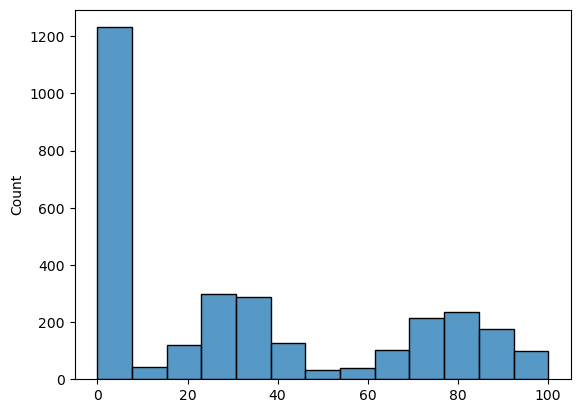

In [506]:
sns.histplot(subtask2)

# Subtask 3

<Axes: >

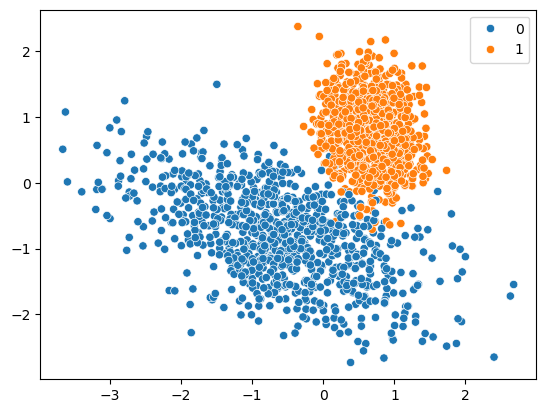

In [507]:
signal_indices = np.where(subtask1 == 1)[0]
X_test_meaningful = X_test_s[signal_indices]

km = KMeans(n_clusters=2, n_init="auto", random_state=seed)
clusters = km.fit_predict(X_test_meaningful)

sns.scatterplot(x=X_test_meaningful[:, 0], y=X_test_meaningful[:, 1], hue=clusters)

In [508]:
subtask3 = np.zeros((X_test_s.shape[0],))
subtask3[signal_indices] = clusters

# Submission

In [509]:
def build_subtask(ans, sid):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["ID"],
        "answer": ans
    })

subtasks = [
    (subtask1, 1),
    (subtask2, 2),
    (subtask3, 3),
]

submission_df = pd.concat([build_subtask(ans, sid) for ans, sid in subtasks])

In [510]:
submission_df.head()

,subtaskID,datapointID,answer
0,1,7776,0.0
1,1,7064,1.0
2,1,2035,1.0
3,1,3982,1.0
4,1,8302,1.0


In [511]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)